# Entendendo o negócio

A Ice é uma loja online que vende videogames em todo o mundo. Para planejar suas campanhas publicitárias, a empresa precisa identificar quais características estão associadas ao sucesso de um jogo e, assim, reconhecer títulos com potencial de vendas.

Este projeto analisa dados históricos disponíveis em fontes abertas, incluindo vendas, avaliações de usuários e especialistas, gêneros, plataformas e classificação etária. O cenário considerado é dezembro de 2016: as conclusões devem apoiar o planejamento de campanhas para 2017. O objetivo é investigar padrões que ajudem a orientar essas decisões, sem pressupor que os dados permitam prever vendas com certeza.

A coluna `rating` registra a classificação atribuída pela ESRB (Entertainment Software Rating Board), órgão que avalia o conteúdo dos jogos e indica a faixa etária recomendada, como Teen (adolescentes) e Mature (adultos).

# Importando as Bibliotecas necessárias:

In [1]:
# Importando as bibliotecas necessárias:
import pandas as pd
import numpy as np
import plotly.express as px
import seaborn as sn
from scipy import stats as st

# Etapa 1. Abrindo o arquivo de dados e estudando as informações gerais

### 1.1. Lendo o arquivo 'games.csv':

In [2]:
games_table = pd.read_csv('../datasets/games.csv')

In [3]:
# carregando uma amostra de 7 linhas do arquivo:
games_table.sample(7)

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
4191,FIFA 12,PC,2011.0,Sports,0.04,0.33,0.00,0.10,NaN,NaN,NaN
9014,Wild ARMs 4,PS2,2005.0,Role-Playing,0.07,0.06,0.00,0.02,69.0,7.3,T
12123,Judie no Atelier: Guramnat no Renkinjutsushi,PS2,2002.0,Role-Playing,0.00,0.00,0.07,0.00,NaN,NaN,NaN
12247,Fallout: Brotherhood of Steel,PS2,2004.0,Role-Playing,0.03,0.03,0.00,0.01,64.0,4.1,M
2125,FIFA Soccer 2005,XB,2004.0,Sports,0.33,0.60,0.00,0.04,81.0,8.7,E
16097,Wand of Fortune: Mirai e no Prologue Portable,PSP,2010.0,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN
14963,Magicka Collection,PC,2011.0,Adventure,0.00,0.02,0.00,0.00,NaN,7.5,T


### 1.2. Imprimindo as informações gerais do arquivo 'games.csv':

In [4]:
games_table.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


Observando as informações gerais e a amostra de dados do arquivo 'games.csv', percebemos os seguintes detalhes:
- Os títulos das colunas não estão em formato padrão 'snake_case';
- Existem valores ausentes nas seguintes colunas: Name, Year_of_Release, Genre, Critic_Score, User_Score, e Rating. Veremos mais adiante se precisaremos trata-los ou não;
- A coluna 'Year_of_Release' deve ter seus dados convertidos para o tipo int;
- A coluna 'User_Score' deve ter seus dados convertidos para o tipo float;

# Etapa 2. Preparando os dados

### 2.1. Convertendo os titulos das colunas para o formato 'snake_case':

In [5]:
# Convertendo os titulos das colunas para minúsculo:
new_columns_lower = []  # Cria uma lista vazia para receber os nomes tratados
for name in games_table.columns:   # Para cada nome de coluna
    name = name.lower()            # Converte o nome para minusculo
    new_columns_lower.append(name) # Adiciona à lista vazia
    
games_table.columns = new_columns_lower   # Atualiza os titulos das colunas para os novos nomes tratados.

In [6]:
# verificando o resultado:
games_table.columns

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')

### 2.2. Verificando a existência de linhas completamente duplicadas:

In [7]:
print(games_table.duplicated().sum())

0


Não existem linhas completamente duplicadas

### 2.3. Tratando os valores ausentes: 

Verificando quantos valores ausentes existem em cada coluna:

In [8]:
games_table.isna().sum()

name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         6701
rating             6766
dtype: int64

Agora sabemos quantos valores ausentes existem em cada coluna. Vamos percorrer cada uma delas tratando esses valores ausentes:

- <strong> Colunas 'name' e 'genre':

Filtrando todas as linhas com valores ausentes em 'name' e 'genre':

In [9]:
mask = (games_table['name'].isna()) & (games_table['genre'].isna())
games_table[mask]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
659,NaN,GEN,1993.0,NaN,1.78,0.53,0.00,0.08,NaN,NaN,NaN
14244,NaN,GEN,1993.0,NaN,0.00,0.00,0.03,0.00,NaN,NaN,NaN


Percebe-se que as linhas que possuem dados ausentes na coluna 'name' são as mesmas que também possuem valores ausentes na coluna   'genre': linhas 659 e 14244, já que temos apenas 2 linhas com valores ausentes em 'name', e 2 linhas com valores ausentes em 'genre'.

Imagina-se que esqueceram de preencher esses dados. Porém, por ser uma quantidade muito pequena de linhas, não vai influenciar na nossa análise. Por isso, vamos deixa-las intactas:

- <strong> Coluna 'year_of_release':

Imagina-se que os valores ausentes nessa coluna pode representar algum dado desconhecido referente ao ano de lançamento. Por esse motivo, e para não perder esses 269 dados, vamos preenche-los com 0:

In [10]:
# Prenchendo os valores ausentes da coluna 'year_of_release' com 0, para representar um dado desconhecido:
games_table['year_of_release'] = games_table['year_of_release'].fillna(0)

# Verificando o resultado:
year_nan = games_table['year_of_release'].isna().sum()
print(f'Agora existem {year_nan} valores ausentes na coluna "year_of_release"')

Agora existem 0 valores ausentes na coluna "year_of_release"


- <strong> Colunas 'critic_score' e 'user_score':

Nota: Na coluna user_score, Como 'tbd' representa valores a serem determinados, então é natural trocálo por NaN. Também é necessário converter user_score para o tipo float

In [11]:
# Renomeando 'tbd' como NaN:
games_table['user_score'] = games_table['user_score'].replace('tbd',np.nan)

In [12]:
# Convertendo 'user_score' para o tipo float:
games_table['user_score'] = games_table['user_score'].astype('float')

In [13]:
# Checando o resultado:
games_table['user_score'].dtype

dtype('float64')

Observe que, em ambas as colunas ('user_score' e 'critic_score'), Os valores nulos representam um grande percentual dos nossos dados. Nesse sentido, deixaremos eles intactos para não compremeter nossa análise.

- <strong> Coluna 'rating':

In [14]:
# Imprimindo a lista de valores únicos da coluna 'rating':
games_table['rating'].unique()

array(['E', nan, 'M', 'T', 'E10+', 'K-A', 'AO', 'EC', 'RP'], dtype=object)

Sabemos que RP representa "ainda não classificado". Dessa forma, podemos substitui-lo por NaN:

In [15]:
games_table['rating'] = games_table['rating'].replace('RP',np.nan)

In [16]:
# Verificando o resultado:
games_table['rating'].unique()

array(['E', nan, 'M', 'T', 'E10+', 'K-A', 'AO', 'EC'], dtype=object)

Imagina-se que os valores NaN dessa coluna representem dados onde não se conhece a classificação rating. Portanto, não vamos altera-los ou exclui-los.

### 2.4. Convertendo os dados para os tipos necessários:

- Coluna 'year_of_release':

Vamos converter os dados dessa coluna para int

In [17]:
games_table['year_of_release'] = games_table['year_of_release'].astype('int')

- Coluna 'user_score':

Já convertemos essa coluna para o tipo float no item anterior (ítem 2.3)

Verificando os resultados:

In [18]:
games_table.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16715 non-null  int64  
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       7590 non-null   float64
 10  rating           9946 non-null   object 
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


### 2.5. Criando uma nova coluna que representa a soma das vendas em todas as regiões:

In [19]:
# Criando a coluna 'total_sales'
games_table['total_sales'] = games_table['na_sales'] + games_table['eu_sales'] + games_table['jp_sales'] + games_table['other_sales']

In [20]:
# Verificando os resultados:
games_table.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN,40.24
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN,31.38


# Etapa 3. Analisando os dados

### 3.1. Analisando quantos jogos são vendidos a cada ano:

Agrupando os jogos pelo ano de lançamento e criando uma tabela para armazenar o resultado:

In [21]:
# Quantidade de jogos lançados por ano, diferente do ano 0 (considerando o ano de lançamento como 0 para dados desconhecidos):
games_per_year = games_table[games_table['year_of_release'] != 0].groupby('year_of_release')['name'].count().reset_index().rename(columns={'name':'games_released'})
games_per_year.head() # Exibindo as primeiras linhas da tabela do agrupamento

,year_of_release,games_released
0,1980,9
1,1981,46
2,1982,36
3,1983,17
4,1984,14


In [22]:
# Exibindo o ano com maior número de lançamentos: 
ano_de_maior_lancamento = games_per_year.loc[games_per_year['games_released'].idxmax()]
print(f'O ano com maior número de lançamentos foi {ano_de_maior_lancamento["year_of_release"]}, com {ano_de_maior_lancamento["games_released"]} jogos lançados.')

O ano com maior número de lançamentos foi 2008, com 1427 jogos lançados.


Construindo um gráfico de linhas para visualizar a tendência dos valores da tabela ao longo dos anos:

In [23]:
# Construindo um gráfico de linhas para visualizar a tendência dos valores da tabela ao longo dos anos:
fig1 = px.line(
    games_per_year,
    x='year_of_release', 
    y='games_released', 
    title='Quantidade de jogos lançados por ano',
    labels={'year_of_release':'Ano de lançamento', 'games_released':'Quantidade de jogos lançados'},
    color_discrete_sequence=['#d616e0']
)
fig1.show()

A partir do gráfico acima, percebemos que a quantidade de jogos eletrônicos lançados aumentou com o passar dos anos, atingindo o seu pico entre 2008 e 2009. Porém, está em uma certa tendência de baixa de 2009 à 2016. Diante disso, podemos projetar mais quedas para os próximos anos a partir de 2017.

### 3.2. Analisando como as vendas variaram de plataforma para plataforma, com base no ano de lançamento de seus títulos:

Vamos agrupar as vendas totais por plataforma para descobrir quais são as top 7 plataformas com mais vendas totais de jogos de videogame:

In [24]:
# Agrupando as vendas totais por plataforma, e ordenando os resultados em ordem decrescente: 
top_platforms_in_sales = games_table.groupby('platform')['total_sales'].sum().reset_index().sort_values(by='total_sales', ascending=False).reset_index(drop=True)
top_platforms_in_sales

,platform,total_sales
0,PS2,1255.77
1,X360,971.42
2,PS3,939.65
3,Wii,907.51
4,DS,806.12
5,PS,730.86
6,GBA,317.85
7,PS4,314.14
8,PSP,294.05
9,PC,259.52


Temos um dado interessante e esperado: O PS2 foi o console que mais vendeu até 2016

Analisando as vendas totais de cada uma das plataformas de videogames ao longo do tempo, com base nos anos de lançamento de seus jogos:

In [25]:
# agregando as vendas totais por plataforma e ano de lançamento, atravéz de uma tabela dinâmica:
# (considerando apenas os anos com dados conhecidos, diferente de 0):
sales_per_year_platform = games_table.pivot_table(index='year_of_release', columns='platform', values='total_sales', aggfunc='sum').reset_index() # Agregando    
# Se livrando dos anos com dados desconhecidos - ano 0 (linha 0 da tabela dinamica):
sales_per_year_platform = sales_per_year_platform.loc[1:]

sales_per_year_platform = sales_per_year_platform.fillna(0) # Substituindo os valores NaN por 0 para simbolizar anos sem vendas
sales_per_year_platform.head() # Exibindo o dataframe resultante

platform,year_of_release,2600,3DO,3DS,DC,DS,GB,GBA,GC,GEN,...,SAT,SCD,SNES,TG16,WS,Wii,WiiU,X360,XB,XOne
1,1980,11.38,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1981,35.68,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1982,28.88,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1983,5.84,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,1984,0.27,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Criando um gráfico de linhas para identificar o comportamento das plataformas de videogame ao longo dos anos:

In [26]:
fig2 = px.line( 
    sales_per_year_platform,
    x='year_of_release',
    y=sales_per_year_platform.columns[1:], # Selecionando todas as colunas, exceto a primeira (ano)
    title='Evolução das Vendas das Maiores Plataformas de Videogames ao Longo dos Anos (com base no ano de lançamento de seus jogos)',
    labels={'year_of_release':'Ano de lançamento dos jogos', 'value':'Vendas totais (em milhões de USD)'},
    color_discrete_sequence=px.colors.qualitative.Dark24,
    markers=True
)   
fig2.update_xaxes(dtick=1, tickangle=90)
fig2.update_layout(legend_title_text='Plataformas')
fig2.show()


Observando o gráfico de linhas acima, fica fácil tirar os seguintes insiders: 

- Os jogos lançados em 2002 e 2004 renderam ao PS2 cerca de 200 milhões de dólares em vendas. Esses anos foram os picos do console mais popular do nosso banco de dados.
- As seguintes plataformas eram populares, porém com o passar do tempo deixaram de vender (pararam de vender a partir de 2010): PS2 (Playstation 2), Nitendo DS, Nitendo Wii. Além do Playstation 1 (PS), que parou de vender a partir de 2002.
- Quanto tempo leva para as novas plataformas aparecerem e as antigas desaparecerem? Para responder a essa pergunta, precisamos analisar os dados do gráfico acima com a seguinte tabela:

In [27]:
games_table_copy = games_table.copy() # criando uma cópia do dataframe original
games_table_copy['year_of_release'] = games_table['year_of_release'].replace(0, np.nan) # devolvendo os valores 0 para NaN na coluna 'year_of_release' da cópia do dataframe
ciclo_de_vida_platforms = games_table_copy.groupby('platform')['year_of_release'].agg(['min','max']).reset_index()
ciclo_de_vida_platforms = ciclo_de_vida_platforms.rename(columns={'min':'first_release_year', 'max':'last_release_year'})
# ordernando o resultado pelo ano do primeiro lançamento:
ciclo_de_vida_platforms = ciclo_de_vida_platforms.sort_values(by='first_release_year').reset_index(drop=True)
ciclo_de_vida_platforms # Exibindo o resultado

,platform,first_release_year,last_release_year
0,2600,1980.0,1989.0
1,NES,1983.0,1994.0
2,PC,1985.0,2016.0
3,DS,1985.0,2013.0
4,GB,1988.0,2001.0
5,GEN,1990.0,1994.0
6,SNES,1990.0,1999.0
7,GG,1992.0,1992.0
8,SCD,1993.0,1994.0
9,NG,1993.0,1996.0


In [28]:
# Criando a coluna 'vida_util' para representar o ciclo de vida de cada plataforma em anos:
ciclo_de_vida_platforms['vida_util'] = ciclo_de_vida_platforms['last_release_year'] - ciclo_de_vida_platforms['first_release_year']
# imprimindo o resultado:     
ciclo_de_vida_platforms.head()

,platform,first_release_year,last_release_year,vida_util
0,2600,1980.0,1989.0,9.0
1,NES,1983.0,1994.0,11.0
2,PC,1985.0,2016.0,31.0
3,DS,1985.0,2013.0,28.0
4,GB,1988.0,2001.0,13.0


In [29]:
# Criando a coluna 'tempo_para_aparecimento' para representar o tempo de aparecimento de uma nova plataforma,
# desde o tempo de aparecimento da plataforma mais antiga (1980):
ciclo_de_vida_platforms['tempo_para_aparecimento'] = ciclo_de_vida_platforms['first_release_year'] - 1980
# imprimindo o resultado:
ciclo_de_vida_platforms.head()

,platform,first_release_year,last_release_year,vida_util,tempo_para_aparecimento
0,2600,1980.0,1989.0,9.0,0.0
1,NES,1983.0,1994.0,11.0,3.0
2,PC,1985.0,2016.0,31.0,5.0
3,DS,1985.0,2013.0,28.0,5.0
4,GB,1988.0,2001.0,13.0,8.0


In [30]:
# Calculando a vida útil média das plataformas:
vida_util_media = ciclo_de_vida_platforms['vida_util'].mean()
# Calculando o tempo médio para aparecimento de uma nova plataforma:
media_tempo_aparecimento = ciclo_de_vida_platforms['tempo_para_aparecimento'].mean()

Agora podemos responder à nossa pergunta:

In [31]:
print(f'A vida útil média das plataformas é de {vida_util_media:.2f} anos, e o tempo médio para aparecimento de uma nova plataforma é de {media_tempo_aparecimento:.2f} anos.')

A vida útil média das plataformas é de 7.61 anos, e o tempo médio para aparecimento de uma nova plataforma é de 17.65 anos.


A vida útil média das plataformas é de aproximadamente 7 anos, e o tempo médio para aparecimento de uma nova plataforma é de aproximadamente 17 anos.. Uma boa informação, não?

### 3.3. Determinando para qual período devemos pegar os nossos dados:

Com base nos dados levantados no item 3.2, onde analisamos o comportamento das franquias de videogames, fica evidente que as franquias que dominam o mercado atualmente (2016) começaram a marcar uma presença mais notória apenas nos últimos 5 anos (em 2011 com o Nitendo WiiU). Dessa forma, consideraremos apenas o período entre 2011 e 2016 para fazer nossas próximas análises e projeções para 2017.

### 3.4. Trabalhando apenas com os dados que consideramos ser relevantes:

In [32]:
# Vamos filtrar o dataframe original para considerar apenas os jogos lançados a partir de 2011:
mask_3 = (games_table['year_of_release'] >= 2011)
games_table_2011 = games_table[mask_3].reset_index(drop=True)
games_table_2011.head() # Exibindo as primeiras linhas do dataframe filtrado

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Grand Theft Auto V,PS3,2013,Action,7.02,9.09,0.98,3.96,97.0,8.2,M,21.05
1,Grand Theft Auto V,X360,2013,Action,9.66,5.14,0.06,1.41,97.0,8.1,M,16.27
2,Call of Duty: Modern Warfare 3,X360,2011,Shooter,9.04,4.24,0.13,1.32,88.0,3.4,M,14.73
3,Call of Duty: Black Ops 3,PS4,2015,Shooter,6.03,5.86,0.36,2.38,NaN,NaN,NaN,14.63
4,Pokemon X/Pokemon Y,3DS,2013,Role-Playing,5.28,4.19,4.35,0.78,NaN,NaN,NaN,14.60


In [33]:
# Exibindo o menor e maior ano de lançamento no dataframe filtrado:
print(f'O menor ano de lançamento no dataframe filtrado é {games_table_2011["year_of_release"].min()}, e o maior ano de lançamento é {games_table_2011["year_of_release"].max()}, como queriamos.')

O menor ano de lançamento no dataframe filtrado é 2011, e o maior ano de lançamento é 2016, como queriamos.


### 3.5. Analisando os dados de vendas relevantes:

- Quais plataformas estão liderando em vendas?

In [34]:
# Agregando as vendas totais por plataforma e ano de lançamento dos seus titulos, atravéz de uma tabela dinâmica:
sales_per_year_platform_relevant = games_table_2011.pivot_table(index='year_of_release', columns='platform', values='total_sales', aggfunc='sum').fillna(0).reset_index() # Agregando
sales_per_year_platform_relevant.head() # Exibindo as primeiras linhas do dataframe filtrado

platform,year_of_release,3DS,DS,PC,PS2,PS3,PS4,PSP,PSV,Wii,WiiU,X360,XOne
0,2011,63.20,26.18,35.03,0.45,156.78,0.00,17.82,4.63,59.65,0.00,143.84,0.00
1,2012,51.36,11.01,23.22,0.00,107.36,0.00,7.69,16.19,21.71,17.56,99.74,0.00
2,2013,56.57,1.54,12.38,0.00,113.25,25.99,3.14,10.59,8.59,21.65,88.58,18.96
3,2014,43.76,0.00,13.28,0.00,47.76,100.00,0.24,11.90,3.75,22.03,34.74,54.07
4,2015,27.78,0.00,8.52,0.00,16.82,118.90,0.12,6.25,1.14,16.35,11.96,60.14


In [35]:
# Exibindo um gráfico de linhas para visualizar a tendência dos valores da tabela ao longo dos anos:
fig3 = px.line( 
    sales_per_year_platform_relevant,
    x='year_of_release',
    y=sales_per_year_platform_relevant.columns[1:], # Selecionando todas as colunas, exceto a primeira (ano)
    title='Evolução das Vendas das Plataformas de Videogames ao Longo dos Anos (considerando apenas os jogos lançados entre 2011 e 2016)',
    labels={'year_of_release':'Ano de lançamento dos jogos', 'value':'Vendas totais (em milhões de USD)'},
    color_discrete_sequence=px.colors.qualitative.Dark24,
    markers=True
)
fig3.update_xaxes(dtick=1, tickangle=90)
fig3.update_layout(legend_title_text='Plataformas')
fig3.show()

Recentemente (2011 até 2016), as plataformas que tiveram mais sucesso em vendas no período foram: PS4, X-Box XOne, X-Box X360 e PS3.

Porém, atualmente (2015 e 2016), as plataformas que estão liderando em vendas são: PS4 e X-Box One.

- Quais estão crescendo ou diminuindo?

As plataformas que perderam mais espaço de 2011 à 2016 são: PS3 e X-Box X360.

Enquanto as plataformas que estão ganhando mais espaço são: PS4 e X-Box One. E as plataformas que estão demonstrando um início de tendência são: PC, PS Vita (PSV) e Nitendo WiiU.

Podemos dizer então que as antigas versões dos consoles PS4 e X-Box One estão dando espaço às novas versões.

- Selecionando as plataformas potencialmente lucrativas:

Diante da análise anterior, constatamos que as plataformas potencialmente lucrativas para 2017 são: PS4, X-Box One, PC, PS Vita (PSV) e Nitendo WiiU.

In [36]:
# Vamos selecionar apenas as vendas dessas 5 plataformas em nosso dataframe games_table_2011:
mask_4 = games_table_2011['platform'].isin(['PS4','XOne','PC','PSV','WiiU'])
potentially_profitable_platforms = games_table_2011[mask_4].reset_index(drop=True)   
potentially_profitable_platforms.sample(5) # Exibindo uma amostra aleatória de 5 linhas do dataframe filtrado

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
1586,Fast Racing Neo,WiiU,2016,Action,0.00,0.01,0.00,0.00,81.0,8.5,E,0.01
1455,Romance of the Three Kingdoms XII,WiiU,2012,Strategy,0.00,0.00,0.02,0.00,NaN,NaN,NaN,0.02
1340,Atelier Firis: The Alchemist of the Mysterious...,PSV,2016,Role-Playing,0.00,0.00,0.02,0.00,NaN,NaN,NaN,0.02
1216,Song of the Deep,PC,2016,Action,0.03,0.00,0.00,0.00,73.0,6.3,E,0.03
220,Dragon Age: Inquisition,PC,2014,Role-Playing,0.33,0.34,0.00,0.06,85.0,5.9,M,0.73


### 3.6. Construindo um diagrama de caixa para as vendas globais de todos os jogos, e analisando os dados:

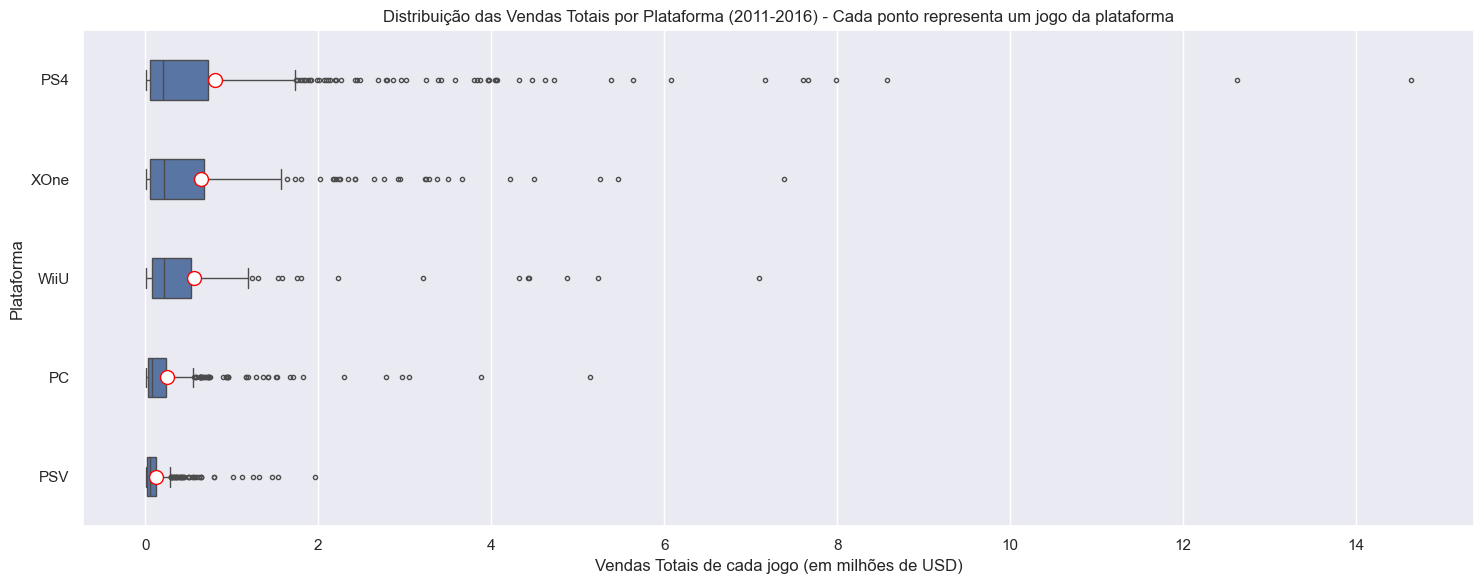

In [37]:
sn.set(rc={'figure.figsize': (15, 6)})  # (largura, altura) em polegadas
ax = sn.boxplot(data=potentially_profitable_platforms, y='platform', x='total_sales', width=0.4, fliersize=3, showmeans=True,
                 meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"red", "markersize":"10"}) # plotando também a média das vendas totais para 
                 #cada plataforma em cima das caixas, marcando a média com um círculo branco com borda vermelha:
ax.set_xlabel('Vendas Totais de cada jogo (em milhões de USD)')
ax.set_ylabel('Plataforma')
ax.set_title('Distribuição das Vendas Totais por Plataforma (2011-2016) - Cada ponto representa um jogo da plataforma')# adicionando título ao gráfico
ax.figure.tight_layout() # ajustando o layout da figura

In [38]:
# Calculando a média e mediana das vendas totais para cada plataforma:
platforms_stats = potentially_profitable_platforms.groupby('platform')['total_sales'].agg(['mean','median']).reset_index()
platforms_stats.rename(columns={'mean':'média','median':'mediana'}, inplace=True)   
platforms_stats # Exibindo a tabela com as estatísticas de cada plataforma

,platform,média,mediana
0,PC,0.251105,0.08
1,PS4,0.801378,0.20
2,PSV,0.125431,0.05
3,WiiU,0.559116,0.22
4,XOne,0.645020,0.22


- Respondendo algumas perguntas importantes:
1. As diferenças nas vendas são significativas?

<strong> Analisaremos as medianas dos dados</strong> para responder a essa pergunta:

Sabemos que a mediana indica que até 50% dos jogos de uma determinada plataforma renderam no total até aquele determinado valor delimitado pela mediana. Nesse contexto, podemos dizer que:

 A partir do gráfico de caixas e da última tabela acima, podemos observar que as plataformas X-Box XOne e Nitendo WiiU apresentam a maior mediana de vendas totais, seguida pela plataforma PS4, indicando que essas plataformas são as que possuem os titulos que mais tendem a retornar em receita. Além disso, as plataformas PC, PSV e WiiU apresentam medianas de vendas mais baixas em comparação com PS4 e XOne, sugerindo que essas plataformas podem ter um desempenho de vendas menos consistente.

2. E quanto ás vendas médias em cada plataforma?

 A partir do gráfico de caixas e da tabela de estatísticas, podemos observar que a plataforma PS4 apresenta a maior média de vendas totais, seguida pela plataforma XOne. Ambas as plataformas também possuem uma distribuição de vendas relativamente ampla, indicando uma variação significativa nas vendas dos jogos lançados nessas plataformas. Além disso, as plataformas PC, PSV e WiiU apresentam médias de vendas mais baixas em comparação com PS4 e XOne, sugerindo que essas plataformas podem ter um desempenho de vendas menos consistente.

 Podemos observar também que a maioria dos jogos em todas as plataformas tem vendas totais abaixo de 5 milhões de USD. No entanto, há uma presença significativa de outliers, especialmente para as plataformas PS4 e XOne, indicando que alguns jogos nessas plataformas alcançaram vendas muito altas, ultrapassando os 20 milhões de USD. Isso sugere que, embora a maioria dos jogos tenha um desempenho de vendas modesto, há títulos excepcionais que conseguem capturar uma grande fatia do mercado e gerar receitas substanciais.
 
  Dessa forma, PS4 e XOne mostram-se bem mais promissores para o próximo ano de 2017, já que são as que possuem as mais fortes assimetrias à direita.

### 3.7. Analisando como as avaliações de usuários e profissionais afetam as vendas do PS4, como uma das duas plataformas com mais relevância para 2017:

- Avaliações dos usuários vs vendas totais:

 Devemos analisar a correlação entre as avaliações dos usuários e as vendas totais dos jogos para a plataforma PS4:

In [39]:
# Plotando um gráfico de dispersão para analisar a correlação entre as avaliações dos usuários e as vendas totais dos jogos para a plataforma PS4:
ps4_games = potentially_profitable_platforms[potentially_profitable_platforms['platform'] == 'PS4'] # Filtrando apenas os jogos da plataforma PS4
scatter_user_sales = px.scatter(
    ps4_games,  
    x='user_score',
    y='total_sales',
    title='Avaliações dos Usuários vs Vendas Totais para Jogos da Plataforma PS4',
    labels={'user_score':'Avaliação dos Usuários', 'total_sales':'Vendas Totais (em milhões de USD)'}
)
scatter_user_sales.show()


In [40]:
# Calculando o índice de correlação de Pearson entre as avaliações dos usuários e as vendas totais dos jogos para a plataforma PS4:
correlation_user_sales = ps4_games['user_score'].corr(ps4_games['total_sales'], method='pearson')
print(f'O índice de correlação de Pearson entre as avaliações dos usuários e as vendas totais dos jogos para a plataforma PS4 é de {correlation_user_sales:.2f}.')  

O índice de correlação de Pearson entre as avaliações dos usuários e as vendas totais dos jogos para a plataforma PS4 é de -0.03.


Com um índice de correlação de -0.03, concluimos que as avaliações dos usuários não afetam diretamente nas vendas totais dos jogos de PS4.

- Avalições dos críticos vs vendas totais:

In [41]:
# Criando um gráfico de dispersão para analisar a correlação entre as avaliações dos críticos e as vendas totais dos jogos para a plataforma PS4:
scatter_critic_sales = px.scatter(
    ps4_games,  
    x='critic_score',
    y='total_sales',
    title='Avaliações dos Críticos vs Vendas Totais para Jogos da Plataforma PS4',
    labels={'critic_score':'Avaliação dos Críticos', 'total_sales':'Vendas Totais (em milhões de USD)'}
)   
scatter_critic_sales.show()
# Calculando o índice de correlação de Pearson entre as avaliações dos críticos e as vendas totais dos jogos para a plataforma PS4:
correlation_critic_sales = ps4_games['critic_score'].corr(ps4_games['total_sales'], method='pearson')
print(f'O índice de correlação de Pearson entre as avaliações dos críticos e as vendas totais dos jogos para a plataforma PS4 é de {correlation_critic_sales:.2f}.')    

O índice de correlação de Pearson entre as avaliações dos críticos e as vendas totais dos jogos para a plataforma PS4 é de 0.41.


Com um índice de correlação de 0.41, constatamos que as avaliações dos críticos interferem levemente nas vendas totais de jogos de PS4: Existe uma leve correlação positiva. Isso quer dizer que quanto mais bem avaliado é um título pelos críticos, mais esse título tende a vender.

### 3.8. Compararemos as vendas dos mesmos jogos analisados em (3.7.) com o seu desempenho financeiro em outras plataformas:

In [42]:
# Verificando a quantidade de jogos únicos da plataforma PS4:
ps4_games['name'].nunique()

392

Temos 392 jogos de PS4 no total. Vamos analisar o desempenho de vendas de cada um dos top 10 games que mais venderam no total nas outras plataformas do dataframe 'games_table':

In [43]:
# guardando a lista de jogos únicos da plataforma PS4:
ps4_list_games = ps4_games['name'].unique()

In [44]:
# Filtrando o dataframe original para analisar apenas o desempenho de vendas dos jogos de PS4 nas outras plataformas:
# Criando a máscara booleana: nome do jogo está na lista de jogos de PS4 E a plataforma é diferente de PS4:
mask_5 = games_table['name'].isin(ps4_list_games) & (games_table['platform'] != 'PS4') 
ps4_other_platforms = games_table[mask_5].reset_index(drop=True) # Aplicando a máscara ao dataframe original para filtra-lo
ps4_other_platforms.sample(5) # Exibindo uma amostra aleatória de 5 linhas do dataframe filtrado

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
736,Rugby League Live 3,PS3,2015,Action,0.00,0.01,0.00,0.00,NaN,NaN,NaN,0.01
509,The Walking Dead: Season Two,X360,2014,Adventure,0.04,0.05,0.00,0.01,NaN,NaN,NaN,0.10
129,Just Cause 3,XOne,2015,Action,0.44,0.39,0.00,0.08,71.0,7.0,M,0.91
740,Mark McMorris Infinite Air,XOne,2016,Sports,0.01,0.00,0.00,0.00,NaN,7.1,T,0.01
502,Terraria,PSV,2013,Action,0.00,0.01,0.09,0.00,85.0,7.8,T,0.10


In [45]:
# Vamos considerar agora as vendas totais por plataforma dos jogos de PS4 que também venderam em outras plataformas, 
# e depois analisar a contribuição de cada jogo nas vendas totais das plataformas através de um gráfico de barras:
outhers_platforms_sales_ps4 = ps4_other_platforms.pivot_table(index='platform', columns='name', values='total_sales', aggfunc='sum').fillna(0).reset_index() # Agregando
fig4 = px.bar(
    outhers_platforms_sales_ps4,
    x='platform',
    y=outhers_platforms_sales_ps4.columns[1:], # Selecionando todas as colunas, exceto a primeira (plataforma)
    title='Vendas Totais por Plataforma dos Top 10 Jogos de PS4 que Mais Venderam em Outras Plataformas',
    labels={'platform':'Plataforma', 'value':'Vendas Totais (em milhões de USD)'},
    color_discrete_sequence=px.colors.qualitative.Dark24
)
fig4.update_layout(legend_title_text='Jogos de PS4')
fig4.show()

A partir desse gráfico, tiramos as seguintes conclusões:
- PS3, XOne e X360 são as plataformas que vendem mais para os mesmos jogos vendidos no PS4;
- O GTA V performa melhor em franquias da série Playstation e X-Box, com os consoles PS3, X360 e XOne. The Last Of Us performa melhor no PS3, e Call Of Dutty: Black Ops 3 performa melhor no XOne;
- Dentre todas as plataformas que julgamos como potencialmente lucrativas para 2017, a única que manteve esse titulo disparadamente foi o X-Box XOne, seguida do PC;


In [46]:
# Vamos considerar agora as vendas totais por plataforma dos jogos de PS4 que também venderam em outras plataformas, e depois analisar a contribuição de cada gênero nas vendas totais das plataformas através de um gráfico de barras:
ps4_game_platform_counts = ps4_other_platforms.pivot_table(index='platform', columns='genre', values='total_sales', aggfunc='sum').fillna(0).reset_index() # Agregando
fig5 = px.bar( 
    ps4_game_platform_counts,
    x='platform',
    y=ps4_game_platform_counts.columns[1:], # Selecionando todas as colunas, exceto a primeira (plataforma)
    title='Vendas Totais por Plataforma dos Jogos de PS4 que Mais Venderam em Outras Plataformas, por Gênero',
    labels={'platform':'Plataforma', 'value':'Vendas Totais (em milhões de USD)'},
    color_discrete_sequence=px.colors.qualitative.Dark24
)
fig5.update_layout(legend_title_text='Gêneros')
fig5.show()

A partir desse gráfico, tiramos as seguintes conclusões sobre os jogos lançados no PS4:
- O gênero racing começou a ser explorado notoriamente no XOne;
- O gênero Sports é significativamente mais explorado no PS3, X360 e XOne;
- Os gêneros mais explorados do XOne são: Action, Shooter e Sports;
- Jogos Misc tem mais performace no Wii, X360 e PS3;

### 3.9. Analisando a distribuição geral de jogos por gênero:

In [47]:
# Analisando a distribuição geral de jogos por gênero no dataframe games_table_2011:
genre_counts = games_table_2011['genre'].value_counts().reset_index().rename(columns={'index':'genre', 'genre':'count'})
# Analisando a distribuição geral de jogos por gênero no dataframe games_table_2011:
genre_counts = (
    games_table_2011['genre']
    .value_counts()
    .rename_axis('genre')
    .reset_index(name='count')
)

fig6 = px.bar(
    genre_counts,
    x='genre',
    y='count',
    title='Distribuição Geral de Jogos por Gêneros, considerando os dados de 2011 à 2016',
    labels={'genre': 'Gênero', 'count': 'Quantidade de Jogos'},
    color_discrete_sequence=["#bd16ff"]
)
fig6.show()
fig6.show()

A partir da leitura desse gráfico de barras, podemos tirar as seguintes conclusões:
- Os gêneros com maior projeção de jogos a serem lançados são respectivamente: Action, Role-Playing, Adventure, Sports e Misc;
- Os gêneros menor projeção de jogos a serem lançados são: Puzzle, Strategy, Platform, Simulation e Fighting;

In [48]:
# Analisando as vendas totais por gênero no dataframe games_table_2011:
genre_values = games_table_2011.groupby('genre')['total_sales'].sum().reset_index().sort_values(by='total_sales', ascending=False).reset_index(drop=True)
genre_values = genre_values.rename(columns={'total_sales':'vendas_totais'})

# Exibindo o gráfico de barras com as vendas totais por gênero:
fig7 = px.bar(
    genre_values,
    x='genre',
    y='vendas_totais',
    title='Vendas Totais por Gênero, considerando os dados de 2011 à 2016',
    labels={'genre':'Gênero', 'vendas_totais':'Vendas Totais (em milhões de USD)'},
    color_discrete_sequence=["#ff5400"]
)
fig7.show()

A partir da leitura desse gráfico de barras, podemos tirar as seguintes conclusões:
- Os gêneros com maior projeção de lucro são respectivamente: Action, Shooter, Role-Playing e Sports;
- Os gêneros menor projeção de lucro são: Puzzle, Strategy, Adventure, Simulation e Fighting;

# Etapa 4. Criando um perfil de usuário para cada região

### 4.1. Determinando as cinco plataformas principais para cada região (AN, UE, JP):

In [49]:
games_table_2011.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Grand Theft Auto V,PS3,2013,Action,7.02,9.09,0.98,3.96,97.0,8.2,M,21.05
1,Grand Theft Auto V,X360,2013,Action,9.66,5.14,0.06,1.41,97.0,8.1,M,16.27
2,Call of Duty: Modern Warfare 3,X360,2011,Shooter,9.04,4.24,0.13,1.32,88.0,3.4,M,14.73
3,Call of Duty: Black Ops 3,PS4,2015,Shooter,6.03,5.86,0.36,2.38,NaN,NaN,NaN,14.63
4,Pokemon X/Pokemon Y,3DS,2013,Role-Playing,5.28,4.19,4.35,0.78,NaN,NaN,NaN,14.60


In [50]:
# Vamos agrupar as vendas do japão por plataforma no dataframe games_table_2011, e pegar as 5 plataformas com maiores vendas no Japão:
jp_sales_by_platform = games_table_2011.groupby('platform')['jp_sales'].sum().reset_index().sort_values(by='jp_sales', ascending=False).reset_index(drop=True)
top_5_jp_platforms = jp_sales_by_platform.head(5).rename(columns={'platform':'jp_platform'})   
top_5_jp_platforms

,jp_platform,jp_sales
0,3DS,100.62
1,PS3,49.39
2,PSP,24.04
3,PSV,21.84
4,PS4,15.96


In [51]:
# Vamos agrupar as vendas da américa do norte por plataforma no dataframe games_table_2011, e pegar as 5 plataformas com maiores vendas da América do norte:
na_sales_by_platform = games_table_2011.groupby('platform')['na_sales'].sum().reset_index().sort_values(by='na_sales', ascending=False).reset_index(drop=True)
top_5_na_platforms = na_sales_by_platform.head(5).rename(columns={'platform':'na_platform'})   
top_5_na_platforms

,na_platform,na_sales
0,X360,226.80
1,PS3,168.26
2,PS4,108.74
3,XOne,93.12
4,3DS,82.65


In [52]:
# Vamos agora agrupar as vendas da Europa por plataforma no dataframe games_table_2011, e pegar as 5 plataformas com maiores vendas na Europa:
eu_sales_by_platform = games_table_2011.groupby('platform')['eu_sales'].sum().reset_index().sort_values(by='eu_sales', ascending=False).reset_index(drop=True)
top_5_eu_platforms = eu_sales_by_platform.head(5).rename(columns={'platform':'eu_platform'})
top_5_eu_platforms

,eu_platform,eu_sales
0,PS3,163.10
1,PS4,141.09
2,X360,117.10
3,3DS,61.27
4,PC,56.70


Vamos agora calcular as quotas de mercado de cada plataforma em cada região:

In [53]:
# Vamos criar uma coluna no dataframe top_5_jp_platforms que indique a participação percentual de cada plataforma nas vendas totais do Japão:
total_jp_sales = jp_sales_by_platform['jp_sales'].sum()  # Calculando as vendas totais do Japão
# Calculando a participação percentual, arredondando para duas casas decimais:
top_5_jp_platforms['jp_sales_percentage'] = round((top_5_jp_platforms['jp_sales'] / total_jp_sales) * 100, 2)

top_5_jp_platforms


,jp_platform,jp_sales,jp_sales_percentage
0,3DS,100.62,40.96
1,PS3,49.39,20.11
2,PSP,24.04,9.79
3,PSV,21.84,8.89
4,PS4,15.96,6.50


In [54]:
# Vamos fazer o mesmo para as plataformas da América do norte: criar uma coluna no dataframe top_5_us_platforms que indique a participação 
# percentual de cada plataforma nas vendas totais da América do norte:
total_na_sales = na_sales_by_platform['na_sales'].sum()  # Calculando as vendas totais
# Calculando a participação percentual, arredondando para duas casas decimais:  
top_5_na_platforms['na_sales_percentage'] = round((top_5_na_platforms['na_sales'] / total_na_sales) * 100, 2)   

top_5_na_platforms

,na_platform,na_sales,na_sales_percentage
0,X360,226.80,27.33
1,PS3,168.26,20.28
2,PS4,108.74,13.10
3,XOne,93.12,11.22
4,3DS,82.65,9.96


In [55]:
# Por fim, vamos fazer o mesmo para as plataformas da Europa: criar uma coluna no dataframe top_5_eu_platforms que indique a participação percentual de cada plataforma nas vendas totais da Europa:
total_eu_sales = eu_sales_by_platform['eu_sales'].sum()  # Calculando as vendas totais da Europa
# Calculando a participação percentual, arredondando para duas casas decimais:  
top_5_eu_platforms['eu_sales_percentage'] = round((top_5_eu_platforms['eu_sales'] / total_eu_sales) * 100, 2)

top_5_eu_platforms  

,eu_platform,eu_sales,eu_sales_percentage
0,PS3,163.10,24.35
1,PS4,141.09,21.06
2,X360,117.10,17.48
3,3DS,61.27,9.15
4,PC,56.70,8.47


Vamos criar gráficos de barras para representar esses dados:

In [56]:
# Criando gráficos de barras para representar esses dados:
# Gráfico para as plataformas do Japão:
fig8 = px.bar(
    top_5_jp_platforms,
    x='jp_platform',
    y='jp_sales_percentage',
    title='Participação Percentual das Top 5 Plataformas nas Vendas Totais do Japão (2011-2016)',
    labels={'jp_platform':'Plataforma', 'jp_sales_percentage':'Participação Percentual (%)'},
    color_discrete_sequence=["#16aaff"]
)
fig8.show()
# Gráfico para as plataformas da América do norte:
fig9 = px.bar(
    top_5_na_platforms,
    x='na_platform',
    y='na_sales_percentage',
    title='Participação Percentual das Top 5 Plataformas nas Vendas Totais da América do Norte (2011-2016)',
    labels={'na_platform':'Plataforma', 'us_sales_percentage':'Participação Percentual (%)'},
    color_discrete_sequence=["#ffb416"]
)
fig9.show()
# Gráfico para as plataformas da Europa:
fig10 = px.bar(
    top_5_eu_platforms,
    x='eu_platform',
    y='eu_sales_percentage',
    title='Participação Percentual das Top 5 Plataformas nas Vendas Totais da Europa (2011-2016)',
    labels={'eu_platform':'Plataforma', 'eu_sales_percentage':'Participação Percentual (%)'},
    color_discrete_sequence=["#018634"]
)
fig10.show()


Pela análise dos gráficos acima, fica claro que Europa e América do Norte possuem praticamente as mesmas preferências por plataformas mais modernas, enquanto o Japão opta por plataformas mais antigas. A diferença pode está ligada à preferência de gênero de jogos, que reflete a cultura local.

### 4.2. Determinando os cinco principais gêneros para cada região (AN, UE, JP):

In [57]:
# Vamos fazer a mesma análise para os gêneros mais vendidos em cada região:
# Agrupando as vendas do japão por gênero no dataframe games_table_2011, e pegando os 5 gêneros com maiores vendas no Japão:
jp_sales_by_genre = games_table_2011.groupby('genre')['jp_sales'].sum().reset_index().sort_values(by='jp_sales', ascending=False).reset_index(drop=True)
top_5_jp_genres = jp_sales_by_genre.head(5).rename(columns={'genre':'jp_genre'})   
top_5_jp_genres

,jp_genre,jp_sales
0,Role-Playing,79.87
1,Action,63.62
2,Misc,17.60
3,Fighting,12.38
4,Platform,12.13


In [58]:
# Agrupando as vendas da América do norte por gênero no dataframe games_table_2011, e pegando os 5 gêneros com maiores vendas:
na_sales_by_genre = games_table_2011.groupby('genre')['na_sales'].sum().reset_index().sort_values(by='na_sales', ascending=False).reset_index(drop=True)
top_5_na_genres = na_sales_by_genre.head(5).rename(columns={'genre':'na_genre'})   
top_5_na_genres

,na_genre,na_sales
0,Action,230.92
1,Shooter,194.43
2,Sports,108.70
3,Role-Playing,83.78
4,Misc,69.69


In [59]:
# Agrupando as vendas da Europa por gênero no dataframe games_table_2011, e pegando os 5 gêneros com maiores vendas na Europa:
eu_sales_by_genre = games_table_2011.groupby('genre')['eu_sales'].sum().reset_index().sort_values(by='eu_sales', ascending=False).reset_index(drop=True)
top_5_eu_genres = eu_sales_by_genre.head(5).rename(columns={'genre':'eu_genre'})   
top_5_eu_genres

,eu_genre,eu_sales
0,Action,199.12
1,Shooter,148.02
2,Sports,88.48
3,Role-Playing,62.30
4,Racing,40.58


In [60]:
# Vamos criar uma coluna no dataframe top_5_jp_genres que indique a participação percentual de cada gênero nas vendas totais do Japão:
total_jp_sales = jp_sales_by_genre['jp_sales'].sum()  # Calculando as vendas totais do Japão
# Calculando a participação percentual, arredondando para duas casas decimais:
top_5_jp_genres['jp_sales_percentage'] = round((top_5_jp_genres['jp_sales'] / total_jp_sales) * 100, 2) 
top_5_jp_genres

,jp_genre,jp_sales,jp_sales_percentage
0,Role-Playing,79.87,32.51
1,Action,63.62,25.90
2,Misc,17.60,7.16
3,Fighting,12.38,5.04
4,Platform,12.13,4.94


In [61]:
# Vamos fazer a mesma coisa para os gêneros da América do norte: criar uma coluna no dataframe top_5_na_genres que indique a participação 
# percentual de cada gênero nas vendas totais da América do norte:
total_na_sales = na_sales_by_genre['na_sales'].sum()  # Calculando as vendas totais da América do norte
# Calculando a participação percentual, arredondando para duas casas decimais:
top_5_na_genres['na_sales_percentage'] = round((top_5_na_genres['na_sales'] / total_na_sales) * 100, 2)
top_5_na_genres

,na_genre,na_sales,na_sales_percentage
0,Action,230.92,27.83
1,Shooter,194.43,23.43
2,Sports,108.70,13.10
3,Role-Playing,83.78,10.10
4,Misc,69.69,8.40


In [62]:
# Por fim, vamos fazer o mesmo para os gêneros da Europa: criar uma coluna no dataframe top_5_eu_genres que indique a participação
# percentual de cada gênero nas vendas totais da Europa:
total_eu_sales = eu_sales_by_genre['eu_sales'].sum()  # Calculando as vendas totais da Europa
# Calculando a participação percentual, arredondando para duas casas decimais:
top_5_eu_genres['eu_sales_percentage'] = round((top_5_eu_genres['eu_sales'] / total_eu_sales) * 100, 2)
top_5_eu_genres

,eu_genre,eu_sales,eu_sales_percentage
0,Action,199.12,29.73
1,Shooter,148.02,22.10
2,Sports,88.48,13.21
3,Role-Playing,62.30,9.30
4,Racing,40.58,6.06


In [63]:
# Vamos construir gráficos de barras para representar esses dados:
# Gráfico para os gêneros do Japão:
fig11 = px.bar(
    top_5_jp_genres,
    x='jp_genre',
    y='jp_sales_percentage',
    title='Participação Percentual dos Top 5 Gêneros nas Vendas Totais do Japão (2011-2016)',
    labels={'jp_genre':'Gênero', 'jp_sales_percentage':'Participação Percentual (%)'},
    color_discrete_sequence=["#16aaff"]
)
fig11.show()
# Gráfico para os gêneros da América do norte:
fig12 = px.bar(
    top_5_na_genres,
    x='na_genre',
    y='na_sales_percentage',
    title='Participação Percentual dos Top 5 Gêneros nas Vendas Totais da América do Norte (2011-2016)',
    labels={'na_genre':'Gênero', 'na_sales_percentage':'Participação Percentual (%)'},
    color_discrete_sequence=["#ffb416"]
)
fig12.show()
# Gráfico para os gêneros da Europa:
fig13 = px.bar(
    top_5_eu_genres,
    x='eu_genre',
    y='eu_sales_percentage',
    title='Participação Percentual dos Top 5 Gêneros nas Vendas Totais da Europa (2011-2016)',
    labels={'eu_genre':'Gênero', 'eu_sales_percentage':'Participação Percentual (%)'},
    color_discrete_sequence=["#018634"]
)
fig13.show()

 A partir desses gráficos, vamos analisar algumas semelhanças e diferenças importantes:

As plataformas mais populares no Japão são diferentes das mais populares na América do Norte e na Europa.
- Os gêneros parecem seguir a mesma tendência na Europa e América do Norte, reforçando as semelhanças culturais que existem entre as regiões.
- Em termos de gêneros, o Japão tem uma preferência clara por RPGs, que representam a maior parte das vendas, enquanto na América do Norte e Europa, os gêneros de Ação e Tiro são mais populares. Essas diferenças refletem as preferências culturais e de mercado distintas em cada região, influenciando o desenvolvimento e a comercialização de jogos.   

### 4.3. Vejamos se as classificações do ESRB afetam as vendas em regiões individuais:

In [64]:
games_table_2011['rating'].unique()

array(['M', nan, 'E', 'E10+', 'T', 'EC'], dtype=object)

In [65]:
# Agrupando as vendas das regiões por classificação ESRB:
sales_per_rating = games_table_2011.groupby('rating').agg(
    {'jp_sales':'sum',
    'na_sales':'sum',
    'eu_sales':'sum'}
).reset_index()

sales_per_rating

,rating,jp_sales,na_sales,eu_sales
0,E,36.68,170.17,141.73
1,E10+,11.23,117.72,78.00
2,EC,0.00,0.42,0.00
3,M,26.14,308.45,250.26
4,T,33.39,109.31,83.16


In [66]:
# Construindo um gráfico de barras para mostrar o resultado:
fig14 = px.bar(
    sales_per_rating,
    x = 'rating',
    y = ['jp_sales','na_sales','eu_sales'],
    title='Vendas por classificação ESRB e região (2011-2016):',
    labels={'rating':'Classificação ESRB', 'value':'Vendas totais (em milhões de USD)'},
    color_discrete_sequence=px.colors.qualitative.Dark24,
    barmode='group'
)

# Personalizando a legenda
fig14.update_layout(
    legend=dict(
        title="Região",  # Título da legenda
    )
)

# Renomeando as categorias da legenda
fig14.for_each_trace(lambda t: t.update(name = {
    'jp_sales': 'Japão',
    'na_sales': 'América do Norte', 
    'eu_sales': 'Europa'
}[t.name]))

fig14.show()

É evidente que jogos para a primeira infância (EC) pararam de vender desde 2011.

A partir da análise do gráfico acima, podemos também tirar as seguintes conclusões:

Diferenças significativas:

- Jogos M (Para adultos 17+): Vendem mais na América do Norte e Europa que no Japão.
- Jogos E (Para todos): Têm participação similar em todas as regiões.

Padrões culturais:

- Japão: Pode preferir classificações mais baixas.
- América do Norte: Pode ser mais tolerante a conteúdo mais adulto.

# Etapa 5. Formulando e testando as hipóteses

### 5.1. As classificações médias dos usuários das plataformas Xbox One e PC são as mesmas?

In [67]:
# Filtrando apenas as classificações dos usuários do PC e XOne do dataframe games_table_2011:
users_score_pc = games_table_2011[games_table_2011['platform'] == 'PC']['user_score'].dropna()
users_score_xone = games_table_2011[games_table_2011['platform'] == 'XOne']['user_score'].dropna()

Temos que usar o teste de Hipótese sobre a igualdade das médias de duas populações:

Formulação de Hipóteses:

- $H_{0}$: As classificações médias dos usuários das plataformas Xbox One e PC são as mesmas (media_pc = media_xone).
- $H_{1}$: As classificações médias dos usuários das plataformas Xbox One e PC são diferentes (media_pc $\ne$ media_xone).

Regra de decisão:
Escolhemos o nível de significância $\alpha$ = 5%. O que significa:
- Se p-valor < 0.05: Rejeitamos H₀ (há diferença significativa)
- Se p-valor ≥ 0.05: Não rejeitamos H₀ (não há diferença significativa)

In [68]:
# Realizando o teste de Levene para saber se as variâncias entre as plataformas são iguais:
from scipy.stats import levene

# comparando Xbox One vs PC

# Realizando o teste de Levene
statistic, p_value = levene(users_score_pc, users_score_xone)

print(f"Estatística de Levene: {statistic}")
print(f"Valor-p: {p_value}")

alpha = 0.05
if p_value < alpha:
    print("Rejeitamos a hipótese nula - as variâncias são diferentes (equal_var = False)")
else:
    print("Não rejeitamos a hipótese nula - as variâncias são iguais (equal_var = True)")

Estatística de Levene: 5.516327585628806
Valor-p: 0.01923860682249846
Rejeitamos a hipótese nula - as variâncias são diferentes (equal_var = False)


In [69]:
# Testando as hipóteses:
# Teste 1: Xbox One vs PC
statistic_1, p_value_1 = st.ttest_ind(users_score_xone, users_score_pc, equal_var = False)
print(f"Hipótese 1 - Estatística: {statistic_1:.4f}, p-valor: {p_value_1:.4f}")

alpha = 0.05

# Interpretação:
if p_value_1 < alpha:
    print("❌REJEITAMOS H₀ - Isso significa que as médias são DIFERENTES")
else:
    print("✅NÃO rejeitamos H₀ - Isso significa que as médias são IGUAIS")

Hipótese 1 - Estatística: 0.5061, p-valor: 0.6131
✅NÃO rejeitamos H₀ - Isso significa que as médias são IGUAIS


Concluimos a um nível estatístico de 95% que As classificações médias dos usuários das plataformas Xbox One e PC são as mesmas.

### 5.2. As classificações médias de usuários para os gêneros Action (ação) e Sports (esportes) são diferentes?

In [70]:
# Filtrando apenas as classificações dos usuários de action e sports do dataframe games_table_2011:
users_score_action = games_table_2011[games_table_2011['genre'] == 'Action']['user_score'].dropna()
users_score_sports = games_table_2011[games_table_2011['genre'] == 'Sports']['user_score'].dropna()

Temos que usar o teste de Hipótese sobre a igualdade das médias de duas populações:

Formulação de Hipóteses:

- $H_{0}$: As classificações médias dos usuários para os gêneros action e sports são as mesmas (media_action = media_sports).
- $H_{1}$: As classificações médias dos usuários para os gêneros action e sports são diferentes (media_action $\ne$ media_sports).

Regra de decisão:
Escolhemos o nível de significância $\alpha$ = 5%. O que significa:
- Se p-valor < 0.05: Rejeitamos H₀ (há diferença significativa)
- Se p-valor ≥ 0.05: Não rejeitamos H₀ (não há diferença significativa)

In [71]:
# Realizando o teste de Levene para saber se as variâncias entre os gêneros são iguais:
from scipy.stats import levene

# comparando Xbox One vs PC

# Realizando o teste de Levene
statistic, p_value = levene(users_score_action, users_score_sports)

print(f"Estatística de Levene: {statistic}")
print(f"Valor-p: {p_value}")

alpha = 0.05
if p_value < alpha:
    print("Rejeitamos a hipótese nula - as variâncias são diferentes (equal_var = False)")
else:
    print("Não rejeitamos a hipótese nula - as variâncias são iguais (equal_var = True)")

Estatística de Levene: 18.398485636804207
Valor-p: 1.9840382117910945e-05
Rejeitamos a hipótese nula - as variâncias são diferentes (equal_var = False)


In [72]:
# Testando as hipóteses:
# Teste 2: Action vs Sports  
statistic_2, p_value_2 = st.ttest_ind(users_score_action, users_score_sports, equal_var = False)
print(f"Hipótese 2 - Estatística: {statistic_2:.4f}, p-valor: {p_value_2:.4f}")

alpha = 0.05

# Interpretação:
if p_value_2 < alpha:
    print("❌REJEITAMOS H₀ - Isso significa que as médias entre os GÊNEROS são DIFERENTES")
else:
    print("✅NÃO rejeitamos H₀ - Isso significa que as médias entre os GÊNEROS são IGUAIS")

Hipótese 2 - Estatística: 9.3607, p-valor: 0.0000
❌REJEITAMOS H₀ - Isso significa que as médias entre os GÊNEROS são DIFERENTES


Concluimos a um nível estatístico de 95% que As classificações médias dos usuários para os gêneros action e sports são diferentes.

# Etapa 6. Conclusão Final:

### Resumo do Projeto

Este projeto analisou dados de vendas de videogames da loja Ice para identificar padrões que determinem o sucesso de um jogo e fazer projeções para 2017. Foram analisados 16.715 jogos, com foco especial no período de 2011-2016 (dados mais relevantes).

### Principais Descobertas

#### 1. Tendências Temporais

- Pico da indústria: 2008-2009 foram os anos com maior número de lançamentos (1.427 jogos em 2008)
- Declínio recente: Tendência de queda de 2009 a 2016, sugerindo possível continuação em 2017
- Ciclo de vida das plataformas: Vida útil média de 7,61 anos, com novas plataformas surgindo a cada 17,65 anos
  
💡 O que isso significa:
- Para a Ice: O mercado está se consolidando - menos jogos, mas possivelmente de maior qualidade
- Estratégia: Focar em títulos de alta qualidade ao invés de quantidade
- Ciclo de vida: Plataformas têm prazo de validade - importante planejar transições

#### 2. Plataformas Mais Promissoras para 2017

Top 5 plataformas potencialmente lucrativas:

- PS4

Maior média de vendas (0,80 milhões USD por jogo)

- Xbox One

Segunda maior média (0,65 milhões USD por jogo)

- Nintendo WiiU

Boa mediana de vendas (0,22 milhões USD)

- PC

Crescimento consistente

- PS Vita

Nicho específico, mas estável

💡 O que isso significa:
- ROI mais alto: Investir nessas plataformas gera maior retorno
- Público-alvo: Usuários dessas plataformas gastam mais dinheiro
- Decisão comercial: Priorizar desenvolvimento para PS4 e Xbox One

#### 3. Análise Regional - Perfis de Usuários

América do Norte:
- Plataformas preferidas: Xbox 360 (27,33%), PS3 (20,28%), PS4 (13,10%)
- Gêneros favoritos: Action (27,83%), Shooter (23,43%), Sports (13,10%)

Europa:
- Plataformas preferidas: PS3 (24,35%), PS4 (21,06%), Xbox 360 (17,48%)
- Gêneros favoritos: Action (29,73%), Shooter (22,10%), Sports (13,21%)

Japão:
- Plataformas preferidas: 3DS (40,96%), PS3 (20,11%), PSP (9,79%)
- Gêneros favoritos: Role-Playing (32,51%), Action (25,90%), Misc (7,16%)
  
💡 O que isso significa:
- Localização de produtos: Adaptar catálogo por região
- Marketing direcionado: Campanhas diferentes para cada mercado
- Oportunidade: Jogos de RPG podem ter potencial inexplorado no Ocidente

#### 4. Impacto das Avaliações

- Críticos: Correlação moderada positiva (0,41) com vendas do PS4
- Usuários: Correlação muito baixa (-0,03) com vendas do PS4
- Conclusão: Avaliações profissionais influenciam mais as vendas que avaliações de usuários
  
💡 O que isso significa:
- Investimento em PR: Vale a pena investir em relações com críticos
- Reviews de usuários: Não são determinantes para vendas
- Estratégia de lançamento: Focar em impressionar a imprensa especializada

#### 5. Classificações ESRB

- Jogos M (17+): Dominam vendas na América do Norte e Europa
- Jogos E (Todos): Performance equilibrada em todas as regiões
- Jogos EC: Praticamente inexistentes desde 2011
  
💡 O que isso significa:
- Público-alvo principal: Adultos são o mercado mais lucrativo
- Conteúdo maduro: Não ter medo de temas adultos no Ocidente
- Diversificação: Manter portfólio para todas as idades

#### 6. Testes de Hipóteses

- Xbox One vs PC: ✅ Classificações médias dos usuários são IGUAIS (p-valor = 0,6131)
- Action vs Sports: ❌usuários avaliam diferente
  
💡 O que isso significa:
- Qualidade similar: Jogos multiplataforma mantêm padrão
- Gêneros têm personalidade: Action e Sports atendem expectativas diferentes
- Desenvolvimento: Pode usar mesmos padrões de qualidade entre plataformas

###  Recomendações de Negócios para 2017:

#### Estratégia de Plataformas - Priorização de Investimentos
Foco Principal:

- PS4 e Xbox One: Devem receber 70% dos investimentos em novos títulos
- PS4: Maior média de vendas (0,80 milhões USD por jogo)
- Xbox One: Segunda maior média (0,65 milhões USD por jogo)
  
Investimentos Secundários:

- PC: Manter presença constante (crescimento estável)
- Nintendo WiiU: Explorar nicho específico
- PS Vita: Focar no mercado japonês
  
#### Estratégia Regional - Localização de Produtos
América do Norte e Europa:

- Priorizar gêneros Action e Shooter (representam ~50% das vendas)
- Desenvolver conteúdo Sports como terceira prioridade
- Classificação M (17+) é bem aceita e lucrativa
  
Japão:

- Focar em Role-Playing Games (32,51% do mercado)
- Manter presença forte no Nintendo 3DS
- Adaptar títulos para preferências culturais locais
  
#### Desenvolvimento de Produtos - Gêneros Prioritários
Alta Prioridade (ROI elevado):

- Action: Maior volume de vendas globalmente
- Shooter: Especialmente forte no Ocidente
- Role-Playing: Dominante no Japão, potencial no Ocidente
  
Média Prioridade:

- Sports: Mercado estável e previsível
- Racing: Crescimento na Europa
  
#### Estratégia de Marketing e PR
Investimento em Críticos Especializados:

- Correlação positiva (0,41) entre avaliações profissionais e vendas
- Alocar orçamento para eventos de imprensa e demos exclusivas
- Reviews de usuários têm impacto mínimo nas vendas
  
Campanhas Regionais:

- Ocidente: Enfatizar ação, gráficos e competitividade
- Japão: Destacar narrativa, personagens e progressão
  
#### Gestão de Portfólio - Qualidade vs Quantidade
Tendência do Mercado:

- Mercado em consolidação (menos lançamentos desde 2009)
- Focar em qualidade superior ao invés de volume
- Investir mais recursos por título
  
Ciclo de Vida das Plataformas:

- Preparar transição das plataformas antigas (PS3, Xbox 360)
- Planejar suporte de longo prazo para PS4/Xbox One (vida útil ~7 anos)
  
#### Oportunidades de Mercado Específicas
Mercados Subexplorados:

- RPGs no Ocidente: Grande sucesso no Japão, potencial inexplorado
- Jogos Multiplataforma: Qualidade similar entre PC e Xbox One
- Conteúdo Adulto: Classificação M tem boa aceitação
  
#### Métricas de Sucesso para 2017
KPIs Recomendados:

- Participação de mercado em PS4/Xbox One
- Penetração de títulos Action/Shooter no Ocidente
- Performance de RPGs em mercados não-japoneses
- Scores de críticos especializados